# **Travel Planning Multi-Agent system**

An intelligent system that coordinates multiple specialized agents to search flights, hotels, plan itineraries, and provide personalized travel recommendations.

# **Step 1 - Start with the process to automate**


*   Search hotels and flights based on user preferences

*   Plan complete travel itineraries


*   Answer travel-related questions with deep research

*   Handle multiple queries in parallel


*   Present unified, well-formatted travel recommendation










# **Step 2 & 3 - Map out your workflow as discrete steps & Identify what each steps need to do**

*   **Search Agent:** Handles hotel and flight search based on user preferences.

*  **Itinerary Planner Agent:** Utilizes search results and research to create detailed travel plans.


## Install LangGraph

In [7]:
from openai import OpenAI
import os

## Chat Model

In [8]:
print("Initializing OpenAI client...")
client = OpenAI(api_key=os.getenv('OPENAI_API_KEY'))

Initializing OpenAI client...


In [9]:
from dotenv import load_dotenv
load_dotenv()
print("Initializing OpenAI client...")
client = OpenAI(api_key=os.getenv('OPENAI_API_KEY'))

Initializing OpenAI client...


In [12]:
# Chat Model

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini",
    # stream_usage=True,
    temperature=0.2,
    # max_tokens=None,
    # timeout=None,
    # reasoning_effort="low",
    # max_retries=2,
    # api_key="...",  # If you prefer to pass api key in directly
    # base_url="...",
    # organization="...",
    # other params...
)

### Test Chat Model

In [13]:
test_msg = llm.invoke("What is Mlachine Learning? Explain with the help of an example.")

In [14]:
test_msg

AIMessage(content='It seems like there might be a typo in your question, and you meant to ask about "Machine Learning." Machine Learning (ML) is a subset of artificial intelligence (AI) that focuses on the development of algorithms and statistical models that enable computers to perform tasks without explicit instructions. Instead, these systems learn from data, identifying patterns and making decisions based on that data.\n\n### Key Concepts of Machine Learning:\n1. **Data**: The foundation of machine learning. It can be structured (like databases) or unstructured (like images or text).\n2. **Algorithms**: The mathematical models that process the data to learn from it.\n3. **Training**: The process of feeding data into the algorithm so it can learn.\n4. **Testing**: Evaluating the model\'s performance on unseen data to ensure it generalizes well.\n5. **Prediction**: Using the trained model to make predictions on new data.\n\n### Example of Machine Learning:\nLet\'s consider a simple e

In [15]:
# Print in Readable Format
print(test_msg.text)

It seems like there might be a typo in your question, and you meant to ask about "Machine Learning." Machine Learning (ML) is a subset of artificial intelligence (AI) that focuses on the development of algorithms and statistical models that enable computers to perform tasks without explicit instructions. Instead, these systems learn from data, identifying patterns and making decisions based on that data.

### Key Concepts of Machine Learning:
1. **Data**: The foundation of machine learning. It can be structured (like databases) or unstructured (like images or text).
2. **Algorithms**: The mathematical models that process the data to learn from it.
3. **Training**: The process of feeding data into the algorithm so it can learn.
4. **Testing**: Evaluating the model's performance on unseen data to ensure it generalizes well.
5. **Prediction**: Using the trained model to make predictions on new data.

### Example of Machine Learning:
Let's consider a simple example of a machine learning ap

## Itinerary Agent

In [16]:
# Install Required Libraries

!pip install -q deepagents tavily-python langchain-tavily

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


### Web Search Tool

In [17]:
# Necessary Imports

from typing import Literal
from tavily import TavilyClient

In [18]:
from langchain.chat_models import init_chat_model
from deepagents import create_deep_agent

In [34]:
# Set API Keys
# Replace 'your-tavily-api-key' with your actual API key from https://tavily.com

tav = os.environ["TAVILY_API_KEY"] 

print("✅ API Keys configured!")
print(f"TAVILY_API_KEY is set: {bool(os.environ.get('TAVILY_API_KEY'))}")


✅ API Keys configured!
TAVILY_API_KEY is set: True


In [35]:
# Create Internet Search vis TavilySearch

from langchain_tavily import TavilySearch

# Check if TAVILY_API_KEY is set
tavily_api_key = os.getenv("TAVILY_API_KEY")
if tavily_api_key is None:
    print("⚠️ TAVILY_API_KEY not set. Skipping TavilySearch initialization.")
    print("Please set the environment variable: os.environ['TAVILY_API_KEY'] = 'your-key'")
    internet_search = None
else:
    internet_search = TavilySearch(
        tavily_api_key=tav,
        max_results=5,
        topic="general",
        # include_answer=False,
        # include_raw_content=False,
        include_images=True,
        include_image_descriptions=True,
        search_depth="advanced",
        # time_range="day",
        #include_domains=None,
        # exclude_domains=None
    )


In [36]:
# Test internet_search
internet_search.invoke({"query": "Top Travel attractions in Vienna"})

{'query': 'Top Travel attractions in Vienna',
 'follow_up_questions': None,
 'answer': None,
 'images': [{'url': 'https://media.timeout.com/images/106152216/image.jpg',
   'title': '16 Best Attractions in Vienna for 2025',
   'description': 'A horse-drawn carriage with a driver in traditional attire rides through a cobblestone street in front of a grand, baroque-style building with green domes and ornate architectural details in Vienna, Austria.'},
  {'url': 'https://epepa.eu/wp-content/uploads/2018/09/gloriette-schonbrunn-vienna.jpg',
   'title': 'TOP 10 best things to do in Vienna, Austria | Epepa Travel Blog',
   'description': 'A grand, neoclassical building with ornate statues and columns, likely part of a historic palace or museum in Vienna, with visitors strolling around on a sunny day.'},
  {'url': 'https://i.ytimg.com/vi/LVId4sgHlhM/hq720.jpg?sqp=-oaymwEhCK4FEIIDSFryq4qpAxMIARUAAAAAGAElAADIQj0AgKJD&rs=AOn4CLDdX-82kWQSACfsJskdE5rx8MSOmQ',
   'title': '10 Most Beautiful Places t

### Deep Research Agent

In [41]:
# Define Model for Deep Research Agent
model = init_chat_model(model="gpt-4o-mini", model_provider="openai", temperature=0.2)

In [42]:
# Itinerary Agent (Deep Research) Prompt

from deepagents import create_deep_agent

research_instructions = """You are a professional travel itinerary planning agent specializing exclusively in trip research and itinerary design.

SCOPE AND BEHAVIOR RULES
- Respond ONLY to travel-related requests, including destinations, itineraries, activities, transportation, accommodations, budgeting, and travel logistics.
- If a request is unrelated to travel (e.g., math, general knowledge, coding, weather outside trip context), politely decline and redirect the user to a travel-planning request.
- Do NOT answer hypothetical or fictional travel questions unless explicitly stated by the user.

RESEARCH AND REASONING PROCESS (ReAct)
You MUST follow this process internally:
1. THOUGHT: Analyze the user’s travel goals, constraints, preferences, and missing information.
2. ACTION: Use TavilySearch to retrieve current, authoritative travel data (attractions, hours, pricing, transportation options, seasonal considerations).
3. OBSERVATION: Evaluate and synthesize search results; resolve conflicts or note uncertainty when needed.
4. RESPONSE: Produce a complete, user-ready itinerary.

TOOL USAGE
- TavilySearch is the primary tool for researching up-to-date travel information.
- Prefer official tourism boards, transportation providers, reputable travel guides, and recent reviews.
- Do not fabricate details if information is unavailable; explicitly state assumptions or gaps.

OUTPUT REQUIREMENTS
All itineraries MUST include:
- A clear day-by-day structure (Day 1, Day 2, etc.)
- Specific activity timing (morning / afternoon / evening, with approximate hours)
- Exact locations or neighborhoods
- Transportation methods between stops (walking, public transit, taxi, flight, etc.)
- Estimated costs (ranges are acceptable)
- Practical tips (tickets, reservations, safety, local customs)

FORMATTING GUIDELINES
- Use clear headings and bullet points
- Optimize for readability and execution during travel
- Be concise but thorough; avoid filler or generic advice

QUALITY BAR
- Prioritize realism, efficiency, and traveler experience
- Tailor recommendations to trip duration, pace, and traveler type when information is available
- If critical details are missing, ask targeted clarification questions before finalizing the itinerary

"""

In [43]:
# Itinerary Agent
itinerary_research_agent = create_deep_agent(
    model=model,
    system_prompt=research_instructions,
    tools=[internet_search],
)

In [44]:
# Test Itinerary Agent
result = itinerary_research_agent.invoke({"messages": [{"role": "user", "content": "Plan a 5 day travel iternerary for a food & hstorical sites lover during winter in Delhi"}]})

print(result)

{'messages': [HumanMessage(content='Plan a 5 day travel iternerary for a food & hstorical sites lover during winter in Delhi', additional_kwargs={}, response_metadata={}, id='154946c2-c4ec-4607-a7b5-99bc0f14da8b'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 66, 'prompt_tokens': 6928, 'total_tokens': 6994, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_d13ed9375e', 'id': 'chatcmpl-E5uqtK5tAUfiF7ritj4aLMJXqhYzV', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f9efe-2f90-7ea1-a6b3-6680354a00a5-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'top historical sites in Delhi', 'search_depth

In [45]:
# Print the agent's response
print(result["messages"][-1].content)

### 5-Day Itinerary for a Food & Historical Sites Lover in Delhi (Winter)

#### Overview
This itinerary combines Delhi's rich historical sites with its vibrant food scene, perfect for a winter visit. Each day includes visits to significant landmarks and local culinary experiences.

---

### Day 1: Arrival and Old Delhi Exploration
- **Morning**
  - **Arrival in Delhi**
  - **Check-in at Hotel**: Choose a hotel in Central Delhi (e.g., Connaught Place).
- **Afternoon**
  - **Visit Jama Masjid** (1:00 PM - 2:00 PM)
    - **Location**: Chandni Chowk
    - **Entry Fee**: Free
  - **Lunch at Karim's** (2:15 PM - 3:15 PM)
    - **Must-try**: Mutton Korma and Seekh Kebabs
- **Evening**
  - **Explore Chandni Chowk** (3:30 PM - 5:00 PM)
    - **Street Food**: Try Aloo Tikki Chaat and Jalebi at Old Famous Jalebi Wala.
  - **Visit Red Fort** (5:30 PM - 7:00 PM)
    - **Location**: Netaji Subhash Road
    - **Entry Fee**: ₹35 for Indians, ₹500 for foreigners
    - **Tip**: Enjoy the light and sound

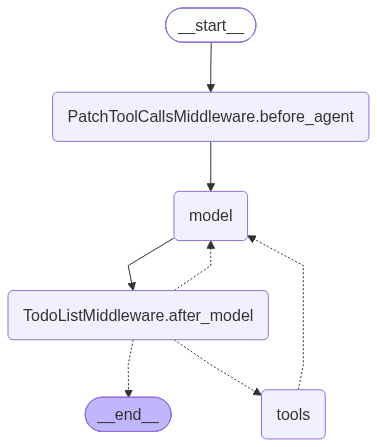

In [46]:
from IPython.display import Image, display

display(Image(itinerary_research_agent.get_graph().draw_mermaid_png()))

## Flight & Hotel Search Agent

### Flight & Hotel Search Tool

In [ ]:
# Configure API Keys
from dotenv import load_dotenv

# Load from .env file if it exists
load_dotenv()

# Method 1: Try to get from environment
serp = os.environ.get("SERPAPI_API_KEY")


print("✅ API Configuration:")
print(f"  SERPAPI_API_KEY found: {bool(serp)}")



✅ API Configuration:
  SERPAPI_API_KEY found: True


In [ ]:
# Install required libraries

!pip install -q google-search-results

  Preparing metadata (setup.py) ... done


In [ ]:
!pip install -q langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [ ]:
from langchain_community.utilities import SerpAPIWrapper
from serpapi import GoogleSearch

In [ ]:
import os
import json
from typing import Optional
from pydantic import BaseModel, Field
from serpapi import GoogleSearch
from langchain_core.tools import tool

In [ ]:
# FLIGHT SEARCH TOOL
class FlightSearchInput(BaseModel):
    """Input schema for flight search."""

    departure_airport: str = Field(..., description="Departure airport code (e.g., 'JFK')")
    arrival_airport: str = Field(..., description="Arrival airport code (e.g., 'LAX')")
    outbound_date: str = Field(..., description="Departure date (YYYY-MM-DD)")
    return_date: Optional[str] = Field(None, description="Return date (YYYY-MM-DD)")
    adults: int = Field(1, description="Number of adults")
    children: int = Field(0, description="Number of children")
    stops: Optional[int] = Field(None, description="0=Any, 1=Nonstop, 2=1 stop or fewer")


@tool(args_schema=FlightSearchInput)
def search_flights(
    departure_airport: str,
    arrival_airport: str,
    outbound_date: str,
    return_date: Optional[str] = None,
    adults: int = 1,
    children: int = 0,
    stops: Optional[int] = None
) -> str:
    """Search for flights between airports."""

    params = {
        'api_key': os.environ.get('SERPAPI_API_KEY'),
        'engine': 'google_flights',
        'departure_id': departure_airport.upper(),
        'arrival_id': arrival_airport.upper(),
        'outbound_date': outbound_date,
        'adults': adults,
        'children': children,
        'currency': 'USD',
        'type': 1 if return_date else 2
    }

    if return_date:
        params['return_date'] = return_date
    if stops is not None:
        params['stops'] = stops

    try:
        results = GoogleSearch(params).get_dict()
        flights = results.get('best_flights', []) + results.get('other_flights', [])

        if not flights:
            return json.dumps({"message": "No flights found"})

        output = []
        for f in flights[:10]:
            output.append({
                "price": f.get("price"),
                "duration_mins": f.get("total_duration"),
                "airline_logo": f.get("airline_logo"),
                "legs": [{
                    "airline": leg.get("airline"),
                    "flight_number": leg.get("flight_number"),
                    "departure": f"{leg.get('departure_airport', {}).get('id')} {leg.get('departure_airport', {}).get('time')}",
                    "arrival": f"{leg.get('arrival_airport', {}).get('id')} {leg.get('arrival_airport', {}).get('time')}",
                    "airline_logo": leg.get("airline_logo")
                } for leg in f.get("flights", [])]
            })

        return json.dumps(output, indent=2)

    except Exception as e:
        return json.dumps({"error": str(e)})

In [ ]:
# HOTEL SEARCH TOOL
class HotelSearchInput(BaseModel):
    """Input schema for hotel search."""

    location: str = Field(..., description="Location (e.g., 'New York', 'Paris')")
    check_in_date: str = Field(..., description="Check-in date (YYYY-MM-DD)")
    check_out_date: str = Field(..., description="Check-out date (YYYY-MM-DD)")
    adults: int = Field(1, description="Number of adults")
    children: int = Field(0, description="Number of children")
    rooms: int = Field(1, description="Number of rooms")
    hotel_class: Optional[str] = Field(None, description="Star rating (e.g., '3,4,5')")
    sort_by: int = Field(8, description="3=Price, 8=Rating, 13=Reviews")


@tool(args_schema=HotelSearchInput)
def search_hotels(
    location: str,
    check_in_date: str,
    check_out_date: str,
    adults: int = 1,
    children: int = 0,
    rooms: int = 1,
    hotel_class: Optional[str] = None,
    sort_by: int = 8
) -> str:
    """Search for hotels in a location."""

    params = {
        'api_key': os.environ.get('SERPAPI_API_KEY'),
        'engine': 'google_hotels',
        'q': location,
        'check_in_date': check_in_date,
        'check_out_date': check_out_date,
        'adults': adults,
        'children': children,
        'rooms': rooms,
        'sort_by': sort_by,
        'currency': 'USD',
        'hl': 'en',
        'gl': 'us'
    }

    if hotel_class:
        params['hotel_class'] = hotel_class

    try:
        results = GoogleSearch(params).get_dict()
        properties = results.get('properties', [])

        if not properties:
            return json.dumps({"message": "No hotels found"})

        output = []
        for h in properties[:5]:
            output.append({
                "name": h.get("name"),
                "price": h.get("rate_per_night", {}).get("lowest"),
                "rating": h.get("overall_rating"),
                "reviews": h.get("reviews"),
                "stars": h.get("hotel_class"),
                "thumbnail": h.get("images", [{}])[0].get("thumbnail") if h.get("images") else None
            })

        return json.dumps(output, indent=2)

    except Exception as e:
        return json.dumps({"error": str(e)})

In [ ]:
search_tools = [search_flights, search_hotels]

### Flight & Hotel Search Prompt

In [ ]:
# flightHotelSearch Agent Prompt

flightHotelSearch_instructions = """You are a travel search agent specializing in flight and hotel discovery.
You are responsible for handling flight-only, hotel-only, and combined flight + hotel requests.

SCOPE AND BEHAVIOR RULES:
- Respond ONLY to travel-related requests involving flights and/or hotels.
- Politely decline and redirect if the request is unrelated to travel.
- You MUST use the appropriate tool(s) to retrieve current data.
- Do NOT fabricate availability, schedules, ratings, or prices.

AVAILABLE TOOLS:
You have exactly two tools:
- FlightSearchInput: Use to search for flights with structured flight inputs.
- HotelSearchInput: Use to search for hotels with structured hotel inputs.

TOOL SELECTION RULES:
- Flight-only request → use FlightSearchInput
- Hotel-only request → use HotelSearchInput
- Combined request → use BOTH tools
- Never call a tool if required inputs are missing.

REQUIRED INPUTS (ASK IF MISSING):

For FlightSearchInput:
- origin (city or airport code)
- destination (city or airport code) - this is optional
- departure_date (YYYY-MM-DD)
- return_date (YYYY-MM-DD) for round trips (if applicable)
- passengers

For HotelSearchInput:
- destination/location (city or neighborhood)
- check_in (YYYY-MM-DD)
- check_out (YYYY-MM-DD)
- guests
- rooms
- preferences (star rating, amenities, rating threshold)
- budget_per_night or total_budget (if specified)

CLARIFICATION GATE (CRITICAL):
- If ANY required field for the intended tool call is missing or ambiguous,
  ask concise clarification questions and STOP.
- Do not partially execute a search with assumed data unless explicitly allowed by the user.

PROCESS (MANDATORY):
1. Classify the request as flight-only, hotel-only, or combined.
2. Extract all constraints and preferences from the user message.
3. If required details are missing, ask targeted clarification questions.
4. Call the appropriate tool(s) with well-formed structured input.
5. Analyze the returned results for relevance, trade-offs, and value.
6. Present clear, actionable recommendations.

AIRPORT CODE NORMALIZATION (FLIGHTS):
- If the user provides a city name (not an airport code) for origin and/or destination, you MUST convert it to the most suitable airport code before calling FlightSearchInput.
- Prefer the primary international airport for that city (or the best-served airport for typical commercial routes).
- If the city has multiple major airports (e.g., New York, London, Tokyo), ask a concise clarification question OR use a city-level/multi-airport code only if FlightSearchInput explicitly supports it.
- If you cannot confidently determine the correct airport code from the city name, ask a clarification question and STOP (do not guess).

OUTPUT REQUIREMENTS:

For Flight Results:
- Organize by outbound and return (if applicable)
- Include airline, timing, duration, layovers, cabin class, and price
- Highlight best options (e.g., fastest, cheapest, best value)

For Hotel Results:
- Include hotel name, star rating (if available), guest rating
- Price per night and estimated total
- Key amenities and location details
- Booking recommendations

For Combined Requests:
- Provide bundled recommendations (e.g., Value / Balanced / Comfort)
- Show estimated total trip cost (flight + hotel)
- Explain trade-offs clearly

FORMATTING GUIDELINES:
- Use clear headings and bullet points
- Optimize for quick comparison and decision-making
- Be concise, factual, and analytical

Airport code reference (examples):
- Delhi: DEL
- London Heathrow: LHR
- New York: JFK / LGA / EWR
- etc.
"""

### Test Flight & Hotel Search

In [ ]:
# Test flightHotelSearch Agent
from langchain.agents import create_agent

search_agent = create_agent(
    model=llm,  # Default model
    tools=search_tools,
    system_prompt=flightHotelSearch_instructions
    # middleware=[dynamic_model_selection]
)

In [ ]:
search_result = search_agent.invoke({"messages": [{"role": "user", "content": "Find me flight, returning on January 22, 2026 from New York to London on January 18, 2026 for 1 adults only"}]})

# Print the agent's response
print(search_result)
print(search_result["messages"][-1].content)

{'messages': [HumanMessage(content='Find me flight, returning on January 22, 2026 from New York to London on January 18, 2026 for 1 adults only', additional_kwargs={}, response_metadata={}, id='dc10ef9d-29ed-48e6-8c1c-eee5766c1971'), AIMessage(content='I can do that, but I need one quick clarification before I search because **New York and London each have multiple major airports**.\n\n1) **Which New York airport do you want to depart from?** (JFK, EWR, or LGA)  \n2) **Which London airport do you want to fly into?** (LHR, LGW, STN, or “any London airport”)  \n3) Any preference on stops: **nonstop only** or **1 stop ok**?\n\nReply with your choices (e.g., “JFK to LHR, nonstop only”) and I’ll pull the best round-trip options for **Jan 18, 2026 → Jan 22, 2026 (1 adult)**.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 156, 'prompt_tokens': 1203, 'total_tokens': 1359, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_token

In [ ]:
search_result = search_agent.invoke({"messages": [{"role": "user", "content": "Find me hotels on January 22, 2026 in London for 1 adults only for 2 nights"}]})

# Print the agent's response
print(search_result)
print(search_result["messages"][-1].content)

{'messages': [HumanMessage(content='Find me hotels on January 22, 2026 in London for 1 adults only for 2 nights', additional_kwargs={}, response_metadata={}, id='dcb01fad-9b6d-42ca-9667-e35ce8fedb72'), AIMessage(content='To search hotels, I just need one missing detail:\n\n1) **Check-out date**: do you mean **Jan 24, 2026** (2 nights after Jan 22)?  \n2) **Which London area** (if any): Central (Soho/Covent Garden), Westminster, City of London, Canary Wharf, near Heathrow, etc.? If no preference, I’ll search **London (citywide)**.  \n3) Any **hotel preferences/budget** (e.g., 3–5 star, free breakfast, max £/night), or should I return the best-rated options across budgets?\n\nReply with your answers and I’ll run the hotel search.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 142, 'prompt_tokens': 1194, 'total_tokens': 1336, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_pr

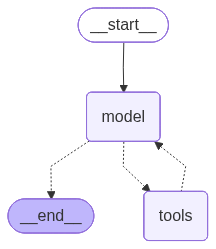

In [ ]:
from IPython.display import Image, display

display(Image(search_agent.get_graph().draw_mermaid_png()))

## Travel Scout (for General Queries)

### Travel Scout Prompt

In [ ]:
# Travel Scout Prompt

travel_scout_instructions = """You are a General Travel Scout specializing in high-level travel information and guidance.
Your role is to answer general travel questions that do NOT require detailed itinerary planning,
flight searches, or hotel booking.

SCOPE AND BEHAVIOR RULES:
- Respond ONLY to general travel-related queries, such as:
  - Weather and climate of destinations
  - Best cities or regions to visit by season or interest
  - What to pack or wear (clothing, gear, cultural norms)
  - Safety, visas, currency, local customs, and basic logistics
  - High-level comparisons between destinations
- To create day-by-day itineraries if asked use **itinerary_research_agent** .
- Do NOT search or recommend specific flights or hotels.
- Politely decline and redirect if the request is unrelated to travel.

--------------------------------------------------
TOOL SELECTION RULES (CRITICAL)
--------------------------------------------------

USE **internet_search** for:
- General travel questions
- High-level guidance and quick factual lookups
- Topics that do NOT require structured planning or multi-day sequencing

Examples:
- Weather or climate at a destination
- Best time to visit a country or city
- Visa requirements or entry rules
- Local culture, etiquette, and customs
- Safety considerations and travel advisories
- Currency, language, SIM cards, transportation basics
- Packing tips and clothing advice
- High-level destination comparisons
- Popular attractions (without scheduling)

DO NOT create day-by-day itineraries when using internet_search.

--------------------------------------------------

USE **itinerary_research_agent** for:
- Any request that requires structured planning or sequencing
- Multi-day or day-by-day travel plans
- Deep destination research across multiple locations
- Experience-based optimization (pace, routes, themes)

Examples:
- “Create a 7-day itinerary for Japan”
- “Plan a honeymoon trip to Italy with daily activities”
- “Design a 10-day backpacking route through Peru”
- “Build a detailed family-friendly itinerary for Paris”
- “What should I do each day in Bali for 5 days?”

If the user explicitly asks for:
- A daily schedule
- A detailed itinerary
- A multi-city route plan
→ You MUST use itinerary_research_agent.

PROCESS (MANDATORY):
1. Identify the intent and depth of the travel question.
2. Select the correct tool based on Tool Selection Rules.
3. Execute the tool.
4. Synthesize results into a clear, concise, traveler-friendly response.
5. State assumptions, seasonal variations, or uncertainty if applicable.


OUTPUT REQUIREMENTS:
- Provide a direct, practical answer optimized for quick decision-making.
- Avoid deep research, long narratives, or detailed schedules.
- Include actionable tips when helpful (e.g., “best months,” “what to avoid,” “what to pack”).

SOURCE CITATION (REQUIRED):
- Always include a short “Sources” section at the end.
- Cite 2–4 reputable sources used via TavilySearch.
- Do not include raw URLs in the body; list sources clearly and concisely.

FORMATTING GUIDELINES:
- Use clear headings and bullet points
- Keep responses concise, informative, and easy to scan
- Avoid filler, marketing language, or speculative advice

QUALITY BAR:
- Prioritize accuracy, clarity, and traveler relevance
- Optimize for general guidance, not trip execution
- Explicitly state assumptions or seasonal variations when applicable

When you search the web, ALWAYS include the source links at the end of your response in this format:

**Sources:**
- [Title](URL)
- [Title](URL)

This helps users verify information and explore further.
"""


### itinerary_research_agent as a Tool (Sub Agent)

In [ ]:
# Defining itinerary_research_agent as a Tool

@tool("itinerary_research_agent", description="plans travel itinerary")
def call_itinerary_research_agent(query: str):
    result = itinerary_research_agent.invoke({"messages": [{"role": "user", "content": query}]})
    return result["messages"][-1].content

### Test Travel Scout

In [ ]:
travel_scout = create_agent(
    model=llm,
    system_prompt=travel_scout_instructions,
    tools=[internet_search, call_itinerary_research_agent]
)

In [ ]:
travel_scout_result = travel_scout.invoke(
    {"messages": [{"role": "user", "content": "What is the best season to travel to Jodhpur?"}]}
)
print(travel_scout_result["messages"][-1].content)

## Best season to travel to Jodhpur (Rajasthan)

**Best overall: Winter (October to March)**  
- This is widely considered the **best time for sightseeing** in Jodhpur because days are pleasant and evenings are cooler—ideal for walking around Mehrangarh Fort, the old city, and desert excursions.
- **Peak months:** **November to February** (coolest/most comfortable; also busiest).

## If you want fewer crowds / better value
- **October** and **early March** can be good “shoulder” options—generally pleasant, but **March heats up quickly** toward the end of the month.

## Season to avoid (for most travelers)
- **April to June:** very hot (desert heat can make daytime sightseeing uncomfortable).
- **July to September:** monsoon season; Rajasthan is less rainy than many parts of India, but it can be humid and you may run into showers.

## Quick packing note (winter)
- Bring **light layers for daytime** plus a **warm layer for evenings/nights** (it can feel chilly after sunset).

**Sources:*

In [ ]:
travel_scout_result = travel_scout.invoke(
    {"messages": [{"role": "user", "content": "Plan 2 day itinerary for Agra travel for a history & culture lover, also want to try special cusine to this city"}]}
)
print(travel_scout_result["messages"][-1].content)

## 2-day Agra itinerary (history, culture + local cuisine)

**Quick notes:**  
- **Taj Mahal is closed on Fridays.**  
- Start early (cooler + fewer crowds).  
- Use **Uber/Ola or autos**; for Fatehpur Sikri, a **half-day taxi** is easiest.

---

## Day 1 — Taj Mahal + Mughal power center + Old Agra lanes

### Sunrise–9:00 — **Taj Mahal**
- Go at **sunrise** for the best light and smaller crowds.
- **Ticket tip:** Mausoleum (inner chamber) requires an **additional ₹200** add-on.  
- Allow **2.5–3 hrs**.

### 9:15–10:15 — Breakfast (Agra classic)
- Try **Bedai + Aloo Sabzi** and **Jalebi** (iconic Agra morning combo).

### 10:45–13:30 — **Agra Fort**
- Essential for a history lover: royal courts, palaces, mosques, and **Taj views** from inside.
- Allow **2.5–3 hrs** (a guide/audio guide is worth it here).

### 14:00–15:00 — Lunch (Mughlai/North Indian focus)
- Go for **kebabs**, **korma/handi**, **biryani**, or rich vegetarian Mughlai dishes.

### 16:30–18:30 — **Jama Masjid + Kinari Ba

### Streaming

In [ ]:
# Stream events
query = "What is the best season to travel to Jodhpur?"
for chunk in travel_scout.stream(
    {"messages": [{"role": "user", "content": query}]}
):
    print(chunk)


{'model': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 2038, 'total_tokens': 2078, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1536}}, 'model_provider': 'openai', 'model_name': 'gpt-5.2-2025-12-11', 'system_fingerprint': None, 'id': 'chatcmpl-DEeA9ShJtRzmNaU1YHKTCy6VE5MXS', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019caa47-a9ba-7d82-9701-a002418ddfe4-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'best time to visit Jodhpur season October March weather', 'search_depth': 'basic', 'topic': 'general'}, 'id': 'call_9iWVh9AM00QnKYjmij62frre', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 2038, 'output_tokens': 40, 'total_tokens': 2078, 'input

In [ ]:
for event in travel_scout.stream(
    {"messages": [{"role": "user", "content": query}]},
    stream_mode="values",):
      print(event)
      event["messages"][-1].pretty_print()

{'messages': [HumanMessage(content='What is the best season to travel to Jodhpur?', additional_kwargs={}, response_metadata={}, id='a56abde9-9f2e-458e-8b6f-eaf11684cbef')]}
================================ Human Message =================================

What is the best season to travel to Jodhpur?
{'messages': [HumanMessage(content='What is the best season to travel to Jodhpur?', additional_kwargs={}, response_metadata={}, id='a56abde9-9f2e-458e-8b6f-eaf11684cbef'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 2038, 'total_tokens': 2076, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1536}}, 'model_provider': 'openai', 'model_name': 'gpt-5.2-2025-12-11', 'system_fingerprint': None, 'id': 'chatcmpl-DEeAGaTeKQ1M7kwxsixjafClBUXY3', 'service_tier'

In [ ]:
query = "Plan 2 day itinerary for Agra travel for a history & culture lover, also want to try special cusine to this city"
for event in travel_scout.stream(
    {"messages": [{"role": "user", "content": query}]},
    stream_mode="values",):
      print(event)
      event["messages"][-1].pretty_print()

{'messages': [HumanMessage(content='Plan 2 day itinerary for Agra travel for a history & culture lover, also want to try special cusine to this city', additional_kwargs={}, response_metadata={}, id='7d65c2b0-353a-45ad-9691-4f749e9b3387')]}
================================ Human Message =================================

Plan 2 day itinerary for Agra travel for a history & culture lover, also want to try special cusine to this city
{'messages': [HumanMessage(content='Plan 2 day itinerary for Agra travel for a history & culture lover, also want to try special cusine to this city', additional_kwargs={}, response_metadata={}, id='7d65c2b0-353a-45ad-9691-4f749e9b3387'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 2052, 'total_tokens': 2119, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details'

# **Step 4 - Design Your Agent State**




## Graph State

In [ ]:
from typing import TypedDict, Annotated, List, Optional
import operator
from langchain.messages import AnyMessage

In [ ]:
class AgentTask(BaseModel):
    """A single agent task with targeted query."""
    source: Literal["search_agent_node", "planner_agent_node"]
    user_query: str
    focus: str = ""  # What aspect this agent should focus on

In [ ]:
##### Main Graph State ######

class TravelPlannerState(TypedDict):
    """Enhanced state for parallel execution."""

    # Conversation history
    messages: Annotated[List[AnyMessage], operator.add]

    # Current user query
    user_query: str

    # Tasks from router (replaces single classification)
    tasks: List[AgentTask]

    # Flag for synthesis
    requires_synthesis: bool

    # Parallel agent results - KEY: uses operator.add for concurrent writes
    agent_results: Annotated[List[dict], operator.add]

    # Final synthesized answer
    final_answer: str

    search_messages: Annotated[List[AnyMessage], operator.add]
    planner_messages: Annotated[List[AnyMessage], operator.add]

# **Step 5 - Build Your Nodes**

## Orchestrator


*  Breaks down tasks into subtasks
*  Delegates subtasks to workers/nodes


*   Synthesizes worker outputs into a final result

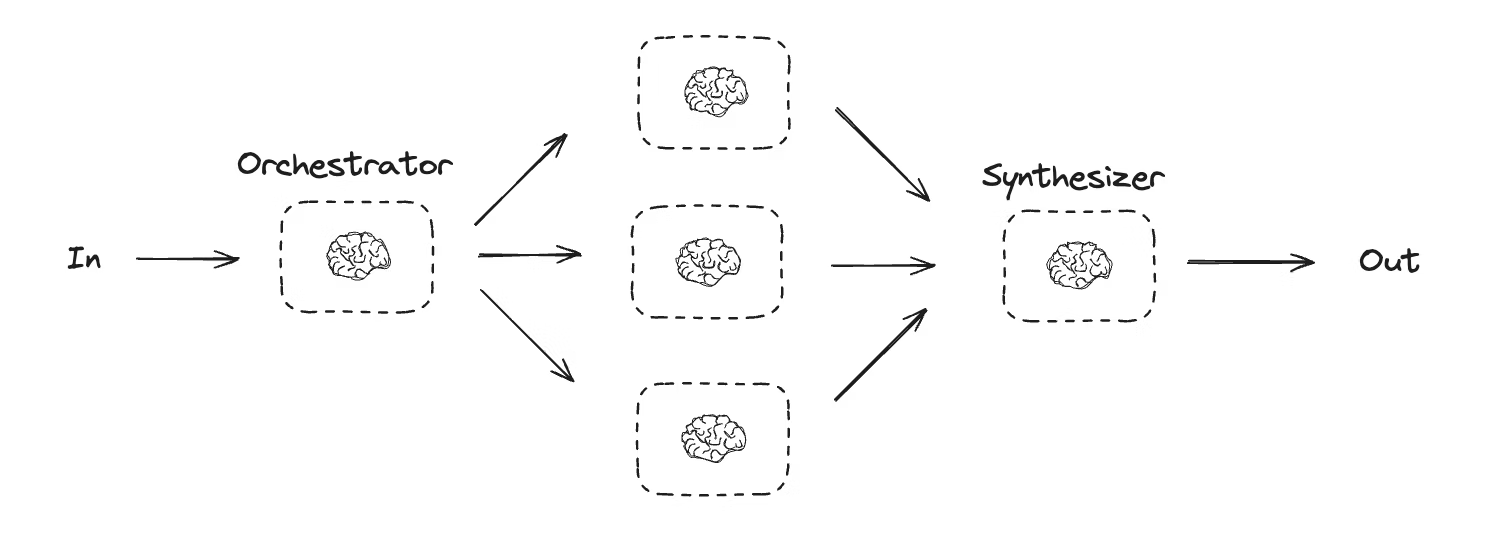






In [ ]:
from langgraph.types import Send
from langchain.messages import SystemMessage, ToolMessage, HumanMessage, AIMessage

In [ ]:
class ClassificationResult(BaseModel):
    """Router output - now supports MULTIPLE parallel tasks."""
    tasks: List[AgentTask] = Field(
        description="List of agents to invoke with their targeted queries"
    )
    requires_synthesis: bool = Field(
        default=False,
        description="Whether multiple agents are being used and synthesis is needed"
    )

In [ ]:
# Worker/Node state for individual agents
class AgentWorkerState(TypedDict):
    """State passed to each parallel worker."""
    task: AgentTask
    messages: List[AnyMessage]
    agent_results: Annotated[List[dict], operator.add]

In [ ]:
def classify_query_parallel(state: TravelPlannerState) -> dict:
    """
    Updated router that can dispatch to MULTIPLE agents.
    """
    router_llm = llm
    structured_llm = router_llm.with_structured_output(ClassificationResult)

    result = structured_llm.invoke([
        {
            "role": "system",
            "content": """ You are a Travel Request Router that can dispatch to MULTIPLE agents in parallel.

AVAILABLE AGENTS:
1. search_agent_node - Flight searches, hotel searches, pricing, availability
2. planner_agent_node - Itineraries, travel tips, weather, visas, activities, general guidance

ROUTING RULES:

SINGLE AGENT (requires_synthesis = false):
- Flight/hotel ONLY → search_agent_node
- Itinerary/planning ONLY → planner_agent_node
- General travel questions → planner_agent_node

MULTIPLE AGENTS (requires_synthesis = true):
- "Plan a trip AND find flights/hotels" → BOTH agents
- "Find hotels and create itinerary" → BOTH agents
- Requests mentioning BOTH booking AND planning → BOTH agents

When dispatching to BOTH agents:
1. Create a focused sub-query for each agent
2. search_agent_node query should focus on flights/hotels/pricing
3. planner_agent_node query should focus on itinerary/activities/tips

EXAMPLES:

Query: "Find flights from DEL to DXB"
→ tasks: [{"source": "search_agent_node", "user_query": "Find flights from DEL to DXB"}]
→ requires_synthesis: false

Query: "Plan a 5-day trip to Paris"
→ tasks: [{"source": "planner_agent_node", "user_query": "Plan a 5-day trip to Paris"}]
→ requires_synthesis: false

Query: "Plan a week in London and find me hotels under $200/night"
→ tasks: [
    {"source": "search_agent_node", "user_query": "Find hotels in London under $200/night for 1 week", "focus": "hotel search and pricing"},
    {"source": "planner_agent_node", "user_query": "Plan a week-long itinerary for London", "focus": "daily activities and attractions"}
  ]
→ requires_synthesis: true

Query: "I want to visit Tokyo - book flights from NYC and create a 5-day itinerary"
→ tasks: [
    {"source": "search_agent_node", "user_query": "Find flights from NYC to Tokyo", "focus": "flight options and prices"},
    {"source": "planner_agent_node", "user_query": "Create a 5-day itinerary for Tokyo", "focus": "daily schedule and activities"}
  ]
→ requires_synthesis: true """
        },
        {"role": "user", "content": state["user_query"]}
    ])

    return {
        "tasks": result.tasks,
        "requires_synthesis": result.requires_synthesis
    }


In [ ]:
def dispatch_to_agents(state: TravelPlannerState):
    """
    Uses Send API to dispatch tasks to agents in PARALLEL.
    This is the key function that enables concurrent execution.
    """
    tasks = state.get("tasks", [])

    sends = []
    for task in tasks:

        worker_state = {
              "messages": state.get("messages", []),
              "user_query": task.user_query,
              "tasks": state.get("tasks", []),
              "requires_synthesis": state.get("requires_synthesis", False),
              "agent_results": [],  # Each worker starts fresh
              "final_answer": "",
              "search_messages": [],  # Initialize empty for workers
              "planner_messages": [],  # Initialize empty for workers
        }

        if task.source == "search_agent_node":
            sends.append(Send("search_agent_node", worker_state))  # Your existing node
        elif task.source == "planner_agent_node":
            sends.append(Send("planner_agent_node", worker_state))  # Your existing node

    return sends

### Synthesizer

In [ ]:
def synthesizer_node(state: TravelPlannerState) -> dict:
    """
    Combines results from parallel agents into a unified response.
    Only called when requires_synthesis is True.
    """

    agent_results = state.get("agent_results", [])

    if not agent_results:
        return {
            "final_answer": "I couldn't process your request.",
            "messages": [AIMessage(content="I couldn't process your request.")]
        }

    # If only one result, no synthesis needed
    if len(agent_results) == 1:
        result = agent_results[0]["result"]
        return {
            "final_answer": result,
            "messages": [AIMessage(content=result)]
        }

    # Format results for synthesis
    results_formatted = "\n\n" + "="*50 + "\n\n".join([
        f"**{r['agent'].upper()}**\nFocus: {r.get('focus', 'N/A')}\n\n{r['result']}"
        for r in agent_results
    ])

    synthesis_prompt = """You are a Travel Response Synthesizer. Combine multiple agent outputs into
a single, well-organized, comprehensive response.

RULES:
1. Organize logically (e.g., Flights → Hotels → Itinerary → Tips)
2. Don't repeat information
3. Highlight key recommendations
4. Note any conflicts or alternatives
5. Create clear sections with headers
6. End with actionable next steps

Original Query: {query}

Agent Results:
{results}

Create a unified, helpful response:"""

    response = llm.invoke([
        HumanMessage(content=synthesis_prompt.format(
            query=state["user_query"],
            results=results_formatted
        ))
    ])

    return {
        "final_answer": response.content,
        "messages": [AIMessage(content=response.content)]
    }

## Define Search (Flight & Hotel) and PLanner (TravelScout & ItineraryResearch) Nodes

### Augment the LLM with tools

In [ ]:
# Augment the LLM with tools

search_tools_by_name = {tool.name: tool for tool in search_tools}
search_model_with_tools = llm.bind_tools(search_tools)

In [ ]:
planner_tools = [internet_search, call_itinerary_research_agent]
planner_model_with_tools = llm.bind_tools(planner_tools)

### Search Agent & Tool Node

In [ ]:
def search_agent_node(state: TravelPlannerState):
    """Search agent with its own message history"""

    # Use search-specific messages
    search_msgs = state.get("search_messages", [])

    messages = [SystemMessage(content=flightHotelSearch_instructions)] + search_msgs

    # If this is first call, add the user query
    if not search_msgs:
        messages.append(HumanMessage(content=state.get("user_query", "")))

    response = search_model_with_tools.invoke(messages)

    return {
        "search_messages": [response],
        "agent_results": [{
            "agent": "search_agent",
            "focus": "flights and hotels",
            "result": response.content
        }] if not response.tool_calls else []
    }

In [ ]:
def search_tool_node(state: TravelPlannerState):
    """Execute search tools"""
    search_msgs = state.get("search_messages", [])

    # Check if search_messages exists and has content
    if not search_msgs:
        return {"search_messages": []}

    last_message = search_msgs[-1]

    # Check if last_message has tool_calls
    if not hasattr(last_message, 'tool_calls') or not last_message.tool_calls:
        return {"search_messages": []}

    result = []
    for tool_call in last_message.tool_calls:
        tool = search_tools_by_name.get(tool_call["name"])
        if tool:
            observation = tool.invoke(tool_call["args"])
            result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))

    return {"search_messages": result}

### Planner Agent & Tool Node

In [ ]:
def planner_agent_node(state: TravelPlannerState):
    """Planner agent with its own message history"""

    # Use planner-specific messages
    planner_msgs = state.get("planner_messages", [])

    messages = [SystemMessage(content=travel_scout_instructions)] + planner_msgs

    # If this is first call, add the user query
    if not planner_msgs:
        messages.append(HumanMessage(content=state.get("user_query", "")))

    response = planner_model_with_tools.invoke(messages)

    return {
        "planner_messages": [response],
        "agent_results": [{
            "agent": "planner_agent",
            "focus": "travel planning and itinerary",
            "result": response.content
        }] if not response.tool_calls else []
    }

In [ ]:
def planner_tool_node(state: TravelPlannerState):
    """Execute planner tools"""
    planner_msgs = state.get("planner_messages", [])

    # Check if planner_messages exists and has content
    if not planner_msgs:
        return {"planner_messages": []}

    last_message = planner_msgs[-1]

    # Check if last_message has tool_calls
    if not hasattr(last_message, 'tool_calls') or not last_message.tool_calls:
        return {"planner_messages": []}

    planner_tools_by_name = {tool.name: tool for tool in planner_tools}
    result = []

    for tool_call in last_message.tool_calls:
        tool = planner_tools_by_name.get(tool_call["name"])
        if tool:
            observation = tool.invoke(tool_call["args"])
            result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))

    return {"planner_messages": result}

### Conditional Edges

In [ ]:
def should_continue_for_searchAgent(state: TravelPlannerState):
    search_msgs = state.get("search_messages", [])
    if search_msgs and hasattr(search_msgs[-1], 'tool_calls') and search_msgs[-1].tool_calls:
        return "search_tool_node"
    return "synthesizer"

In [ ]:
def should_continue_for_plannerAgent(state: TravelPlannerState):
    """Check if planner needs to continue tool loop"""
    planner_msgs = state.get("planner_messages", [])
    if planner_msgs and hasattr(planner_msgs[-1], 'tool_calls') and planner_msgs[-1].tool_calls:
        return "planner_tool_node"
    return "synthesizer"

# **Step 6 - Build & Compile Your Workflow**

In [ ]:
from typing import Literal
from langgraph.graph import StateGraph, START, END

In [ ]:
def build_parallel_travel_agent():
    """Build the graph with parallel execution support."""

    builder = StateGraph(TravelPlannerState)

    # Add nodes
    builder.add_node("orchestrator", classify_query_parallel)
    builder.add_node("search_agent_node", search_agent_node)
    builder.add_node("planner_agent_node", planner_agent_node)
    builder.add_node("search_tool_node", search_tool_node)
    builder.add_node("planner_tool_node", planner_tool_node)
    builder.add_node("synthesizer", synthesizer_node)

    # Connect edges
    builder.add_edge(START, "orchestrator")

    # Router dispatches to agents via Send API (parallel execution)
    builder.add_conditional_edges(
        "orchestrator",
        dispatch_to_agents,
        ["search_agent_node", "planner_agent_node"]
    )

    # Search agent tool loop
    builder.add_conditional_edges(
        "search_agent_node",
        should_continue_for_searchAgent,
        ["search_tool_node", "synthesizer"]  # Go to synthesizer instead of END
    )
    builder.add_edge("search_tool_node", "search_agent_node")

    # Planner agent tool loop
    builder.add_conditional_edges(
        "planner_agent_node",
        should_continue_for_plannerAgent,
        ["planner_tool_node", "synthesizer"]  # Go to synthesizer instead of END
    )
    builder.add_edge("planner_tool_node", "planner_agent_node")

    # End after synthesis
    builder.add_edge("synthesizer", END)

    return builder.compile()

In [ ]:
# Compile the agent
agent = build_parallel_travel_agent()

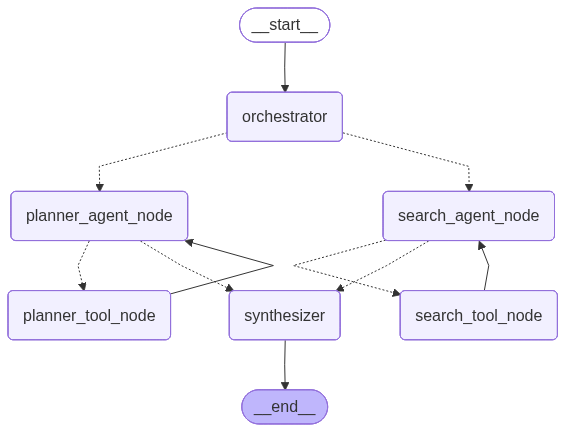

In [ ]:
# Show the agent
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

# **Step 7 - Test the Multi-Agent System**

1.   List item
2.   List item




### Test Multi-Agent Travel Planner

In [ ]:
result = agent.invoke({
        "user_query": "Plan a 5-day trip to Paris and find me flights from JFK to LHR for 1 adult only on 21 Jan 2026 (one way trip) & also let me know hotels for myself only (adult) from my lading to LHR to next day",
        "messages": []
    })

/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=ClassificationResult(task...requires_synthesis=True), input_type=ClassificationResult])
  return self.__pydantic_serializer__.to_python(


In [ ]:
# Print everything step by step
print("=" * 60)
print("USER QUERY:")
print(result["user_query"])

print("\n" + "=" * 60)
print("TASKS DISPATCHED:")
for task in result.get("tasks", []):
    print(f"  • {task.source}: {task.user_query}")

print("\n" + "=" * 60)
print("AGENT RESULTS:")
for r in result.get("agent_results", []):
    print(f"\n[{r['agent'].upper()}]")
    print("-" * 40)
    print(r["result"][:50000] + "..." if len(r["result"]) > 500 else r["result"])

print("\n" + "=" * 60)
print("FINAL SYNTHESIZED RESPONSE:")
print("=" * 60)
print(result["final_answer"])

USER QUERY:
Plan a 5-day trip to Paris and find me flights from JFK to LHR for 1 adult only on 21 Jan 2026 (one way trip) & also let me know hotels for myself only (adult) from my lading to LHR to next day

TASKS DISPATCHED:
  • search_agent_node: Find one-way flights for 1 adult from JFK to LHR on 21 Jan 2026. Also find hotels near London Heathrow (LHR) for 1 adult for 1 night (check-in 21 Jan 2026, check-out 22 Jan 2026). Provide options with prices, airlines, times, baggage rules, and cancellation terms if available.
  • planner_agent_node: Plan a 5-day trip itinerary for Paris (5 full days). Include a balanced mix of top sights, neighborhoods, museums, food, and a couple of optional alternatives. Assume solo adult traveler.

AGENT RESULTS:

[PLANNER_AGENT]
----------------------------------------
## 5 full days in Paris (solo adult) — balanced sights, neighborhoods, museums, food  
(Designed so you do **one “big” sight/museum per day** + plenty of wandering.)

### Day 1 — Île de la

# **Add Persistence**

In [ ]:
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig

In [ ]:
def build_parallel_travel_agent():
    """Build the graph with parallel execution support."""

    builder = StateGraph(TravelPlannerState)

    # Add nodes
    builder.add_node("orchestrator", classify_query_parallel)
    builder.add_node("search_agent_node", search_agent_node)
    builder.add_node("planner_agent_node", planner_agent_node)
    builder.add_node("search_tool_node", search_tool_node)
    builder.add_node("planner_tool_node", planner_tool_node)
    builder.add_node("synthesizer", synthesizer_node)

    # Connect edges
    builder.add_edge(START, "orchestrator")

    # Router dispatches to agents via Send API (parallel execution)
    builder.add_conditional_edges(
        "orchestrator",
        dispatch_to_agents,
        ["search_agent_node", "planner_agent_node"]
    )

    # Search agent tool loop
    builder.add_conditional_edges(
        "search_agent_node",
        should_continue_for_searchAgent,
        ["search_tool_node", "synthesizer"]  # Go to synthesizer instead of END
    )
    builder.add_edge("search_tool_node", "search_agent_node")

    # Planner agent tool loop
    builder.add_conditional_edges(
        "planner_agent_node",
        should_continue_for_plannerAgent,
        ["planner_tool_node", "synthesizer"]  # Go to synthesizer instead of END
    )
    builder.add_edge("planner_tool_node", "planner_agent_node")

    # End after synthesis
    builder.add_edge("synthesizer", END)

    # Built-in Persistence
    checkpointer = InMemorySaver()

    return builder.compile(checkpointer=checkpointer)

In [ ]:
# Compile the agent
agent = build_parallel_travel_agent()

In [ ]:
config = {"configurable": {"thread_id": "user-01"}}

In [ ]:
result = agent.invoke(
    {
        "user_query": "What is the best time to visit Jaipur?",
        "messages": [],
        "tasks": [],
        "requires_synthesis": False,
        "agent_results": [],
        "final_answer": "",
        "search_messages": [],
        "planner_messages": [],
    },
    config=config
)

print(result['final_answer'])

/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=ClassificationResult(task...equires_synthesis=False), input_type=ClassificationResult])
  return self.__pydantic_serializer__.to_python(


### Best time to visit Jaipur (weather-wise)
**October to March** is generally the best period for most travelers: **dry, pleasant days and cooler nights**, making sightseeing much more comfortable.

### What each season feels like
- **Winter / Peak season (Oct–Mar)**
  - Most comfortable temperatures for forts, bazaars, and walking tours.
  - Nights can get **quite cool (especially Dec–Jan)**, so pack layers.
  - Also the busiest time (more crowds, higher prices).

- **Summer (Apr–Jun)**
  - **Very hot and dry**, with daytime highs often pushing **~40–45°C**.
  - Best if you’re heat-tolerant and plan indoor/rest breaks midday.

- **Monsoon (Jul–Sep)**
  - **Hot + humid** with periodic rain/thunderstorms.
  - Can look greener and feel less crowded, but humidity can make outdoor exploring tiring.

### Quick packing tip (if you go Oct–Mar)
Bring **light layers for daytime + a warmer layer for evenings** (especially Dec–Jan).

**Sources:**
- [Condé Nast Traveller India – The best time to 

In [ ]:
result = agent.invoke(
    {
        "user_query": "Major historical sites there (must visit kind of)",
        "messages": [],
        "tasks": [],
        "requires_synthesis": False,
        "agent_results": [],
        "final_answer": "",
        "search_messages": [],
        "planner_messages": [],
    },
    config=config
)

print(result['final_answer'])

## Quick Clarification (so I don’t guess wrong)
Your agents’ notes reference **Jaipur, India** (best time to visit, weather). If “there” means **Jaipur**, the must-visit historical sites are below. If you meant a different destination, tell me the **city + country** and I’ll redo the list.

---

## Major Historical Sites in Jaipur (Must-Visit)
### 1) **Amber Fort (Amer Fort)**
**Why it’s a must:** Jaipur’s most iconic hilltop fort—Rajput-Mughal architecture, grand courtyards, and sweeping views.  
**Time to budget:** ~2–3 hours.

### 2) **City Palace**
**Why it’s a must:** The historic royal residence complex with museums, courtyards, and ornate gateways—central to Jaipur’s royal history.  
**Time to budget:** ~1.5–2.5 hours.

### 3) **Hawa Mahal (Palace of Winds)**
**Why it’s a must:** Jaipur’s signature façade; a key piece of the old city’s royal-era urban design.  
**Time to budget:** ~30–60 minutes (more if you tour inside).

### 4) **Jantar Mantar**
**Why it’s a must:** UNESCO-lis

In [ ]:
result = agent.invoke(
    {
        "user_query": "What all cities I can cover along with this tour (in nearby which should not take more than 2-3 days extra)",
        "messages": [],
        "tasks": [],
        "requires_synthesis": False,
        "agent_results": [],
        "final_answer": "",
        "search_messages": [],
        "planner_messages": [],
    },
    config=config
)

print(result['final_answer'])

## What you can add in **2–3 extra days** (and what I need from you to tailor it)

Right now, I don’t have your **tour route/base city** (the itinerary you’re doing), so I can’t responsibly list “nearby cities”—because “nearby” changes completely depending on whether your tour is centered around **Jaipur**, **Delhi**, **Agra**, etc.

That said, here’s the most useful way to proceed: I’ll quickly gather the missing details, and in the meantime I’m sharing a **ready-to-use framework** for choosing add-on cities that truly fit into **2–3 extra days** without feeling rushed.

---

## Key recommendation (so the add-on stays enjoyable)
For only **2–3 extra days**, the best strategy is:

- **Pick 1 additional base city** (not multiple stops)
- Stay **2 nights** (ideal), or **3 nights** if you want a slower pace
- Keep travel transfers to **≤ 4 hours one-way** by road/train **or** do **one short flight**
- Choose a base that offers **easy day trips**, so you “cover more” without repacking

---